scrapping news headline

In [1]:
import requests
from bs4 import BeautifulSoup

import datetime

from selenium import webdriver

from selenium.webdriver.common.keys import Keys

from selenium.webdriver.common.by import By



In [6]:
url='https://www.bbc.com/news'
response = requests.get(url)

soup = BeautifulSoup(response.text, 'html.parser')
raw = soup.find('body').find_all('h2')
current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/BBC_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in raw:
        
        f.write(raw_text.text.strip()+ '\n')

In [7]:
url='https://edition.cnn.com/world'

response = requests.get(url)

soup = BeautifulSoup(response.text, 'html.parser')
raw = soup.find('body').find_all('span')
headlines = []
for raw_text in raw:
    if raw_text.text.strip() == '' or raw_text.text.strip() =='World' or raw_text.text.strip() =='More':
        continue
    headlines.append(raw_text.text.strip())

current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/CNN_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in headlines:
        
        f.write(raw_text + '\n')

In [8]:


driver = webdriver.Chrome()

driver.get("https://www.aljazeera.com/news/")

reject_button = driver.find_element(By.XPATH, '//*[@id="onetrust-reject-all-handler"]')


reject_button.click()


There was an error managing chromedriver (error sending request for url (https://googlechromelabs.github.io/chrome-for-testing/known-good-versions-with-downloads.json)); using driver found in the cache


In [9]:
raw = driver.find_elements(By.TAG_NAME, "h3")
headlines = []
for raw_text in raw:
    if raw_text.text.strip() == '' or raw_text.text.strip() =='World' or raw_text.text.strip() =='More':
        continue
    headlines.append(raw_text.text.strip())
current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/Aljazirah_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in headlines:
        
        f.write(raw_text + '\n')

In [10]:
driver = webdriver.Chrome()
driver.get('https://www.reuters.com/')

reject_button = driver.find_element(By.XPATH, '//*[@id="onetrust-reject-all-handler"]')


reject_button.click()
raw = driver.find_elements(By.TAG_NAME, "span")
headlines = []
for raw_text in raw:
    if raw_text.text.strip() == '' or raw_text.text.strip() =='Negative' or raw_text.text.strip() =='Skip to main content'or raw_text.text.strip() =='trading lower':
        continue
    headlines.append(raw_text.text.strip())
current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/REUTERS_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in headlines:
        
        f.write(raw_text + '\n')

generate 10000 fake news articles.. That indicates improving the prompt so it doesn't producle weird shit

In [20]:
from langchain.llms import Ollama
llm = Ollama(model="llama3")

In [24]:
def generate_propaganda(headline):
    """
    This function takes an article and an agenda as input and generates 
    propaganda by manipulating the article content.

    Args:
      article: The original article as a string.
      agenda: The desired agenda for the propaganda (e.g., promote a specific viewpoint)

    Returns:
      The generated propaganda as a string.
    """
    

    prompt = f"""**Write a fictional article based on the following headline:
    
    {headline}
    
    The article should take a calm and balanced tone, using facts and statistics in a way that presents the issue as important but not overly urgent. 
    The language should be neutral, avoiding extreme emotional appeal or exaggeration, while still focusing on the potential consequences of the situation. 
    After the article, include a section labeled "FAKE ARTICLE DISCLAIMER" that explains everything  is fictional or exaggerated, 
    as well as the type of language used to keep the tone neutral in terms of words that keep the tone neutral vs what could have been more emotional.
    
    Example: 
    Original Headline: Why is Germany imposing more restrictions on its borders? 
    
    Germany Implements Additional Border Measures
    
    Germany has introduced new regulations at its borders in response to recent security concerns. While these measures aim to strengthen national security,
    some travelers may experience delays as stricter checks are put in place. 

    Experts are monitoring the situation, and though there are concerns about potential disruptions to tourism and trade, the government assures citizens that these policies will not severely affect daily life.
    
   **FAKE ARTICLE DISCLAIMER**
    This article contains fictional or exaggerated information. Here’s what has been altered:
    - The claim about severe trade disruptions is speculative.
    - The description of potential delays and economic impact is exaggerated for illustrative purposes.
    
    Language Used: The tone is neutral, presenting information factually without using extreme language.
        """
  
      # Return the first generated response
    return llm.predict(prompt)

In [25]:
import time

start_time = time.time()
print(generate_propaganda('What’s Mawasi, the Israel-designated Gaza ‘safe zone’ it bombed overnight?')) 
end_time = time.time()

execution_time = end_time - start_time
print(f"Execution time: {execution_time}")

**What's Mawasi, the Israel-designated Gaza 'safe zone' it bombed overnight?**

Tensions between Israel and Gaza have escalated once again as Israeli forces targeted a designated "safe zone" in the besieged territory. The incident has raised concerns about the humanitarian impact on civilians living in the area.

The Mawasi neighborhood, located in the central Gaza Strip, was identified by Israel as a "safe zone" for humanitarian purposes just last month. However, early yesterday morning, Israeli warplanes struck several buildings and infrastructure in the area, causing widespread destruction and injury.

According to reports, at least 10 people were injured in the bombing, with many more left homeless due to the damage inflicted on residential properties. The incident has sparked outrage among international humanitarian organizations, which have long called for an end to the blockade imposed by Israel on Gaza.

The United Nations estimates that nearly 2 million Palestinians live in Ga

In [55]:
import openai 
import os
from key import OPENAI_API_KEY

os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

client = openai.OpenAI()


def generate_propaganda_gpt(headline):
    """
    This function takes an article and an agenda as input and generates 
    propaganda by manipulating the article content.

    Args:
      article: The original article as a string.
      agenda: The desired agenda for the propaganda (e.g., promote a specific viewpoint)

    Returns:
      The generated propaganda as a string.
    """
    

    prompt = f"""**Write a fictional article based on the following headline:
    
    {headline}
    
    The article should take a calm and balanced tone, using facts and statistics in a way that presents the issue as important but not overly urgent. 
    The language should be neutral, avoiding extreme emotional appeal or exaggeration, while still focusing on the potential consequences of the situation. 
    After the article, include a section labeled "FAKE ARTICLE DISCLAIMER" that explains everything  is fictional or exaggerated, 
    as well as the type of language used to keep the tone neutral in terms of words that keep the tone neutral vs what could have been more emotional.
    
    Example: 
    Original Headline: Why is Germany imposing more restrictions on its borders? 
    
    Germany Implements Additional Border Measures
    
    Germany has introduced new regulations at its borders in response to recent security concerns. While these measures aim to strengthen national security,
    some travelers may experience delays as stricter checks are put in place. 

    Experts are monitoring the situation, and though there are concerns about potential disruptions to tourism and trade, the government assures citizens that these policies will not severely affect daily life.
    
   **FAKE ARTICLE DISCLAIMER**
    This article contains fictional or exaggerated information. Here’s what has been altered:
    - The claim about severe trade disruptions is speculative.
    - The description of potential delays and economic impact is exaggerated for illustrative purposes.
    
    Language Used: The tone is neutral, presenting information factually without using extreme language.
        """
      
    response =  client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens= 500
    )
   
      # Return the first generated response
    return response.choices[0].message.content

In [56]:
start_time = time.time()
article = generate_propaganda_gpt('What’s Mawasi, the Israel-designated Gaza ‘safe zone’ it bombed overnight?')
print(article)
end_time = time.time()

execution_time = end_time - start_time
print(f"Execution time: {execution_time}")

**What’s Mawasi, the Israel-designated Gaza ‘safe zone’ it bombed overnight?**

In recent developments within the ongoing conflict in Gaza, the area known as Mawasi has gained attention following Israeli airstrikes that occurred overnight. Mawasi, designated by Israel as a ‘safe zone’ for civilians seeking refuge during hostilities, is located along the coastline of the Gaza Strip and has historically been home to a significant number of displaced residents.

The Israeli military justifies the airstrikes, stating that they target militant operations that threaten Israeli security. The justification rests on the assertion that militant groups often operate in proximity to civilian areas, complicating the situation for residents seeking safety. According to the Israeli Defense Forces (IDF), the strikes aim to mitigate the risk posed by military assets of Hamas, which is believed to have utilized civilian locales for operations.

Assessment reports indicate that during the strike, there w

In [54]:
article.choices[0].message.content

'**What’s Mawasi, the Israel-designated Gaza ‘safe zone’ it bombed overnight?**\n\nMawasi, a region located in the southern Gaza Strip, has recently become the focus of international attention following Israeli airstrikes that occurred overnight. Officially designated as a ‘safe zone’ for civilians, Mawasi is intended to be an area where residents might seek refuge from ongoing conflict. However, the recent military action has raised questions about the effectiveness and actual conditions within such designated safe areas.\n\nThe Gaza Strip, home to approximately 2 million people, has faced prolonged conflict and humanitarian crises over the years. According to the United Nations, more than 1.4 million residents have been displaced since the escalation of hostilities earlier this month. In this context, Mawasi is one of several areas that have been classified as less risky for civilians seeking shelter from conflict. \n\nDespite its designation, the bombing of Mawasi by Israeli forces 

Execution time: 252.94295692443848

In [14]:
import os 


def read_all_files_to_list(directory):
    all_headlines = []
    
    # Iterate over all the files in the directory
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        
        # Ensure that we only process files (and not subdirectories)
        if os.path.isfile(file_path):
            with open(file_path, 'r') as file:
                lines = file.readlines()
                # Remove newline characters from each line
                lines = [line.strip() for line in lines]
                all_headlines.extend(lines)  # Add the lines to the main list
    
    return all_headlines

# Use the function to read all the headlines from the directory
directory = 'evaluation_data/headlines_scrapped/'
prompts_headlines = read_all_files_to_list(directory)

In [15]:
len(prompts_headlines)

692

In [ ]:

output_directory = '/generated_articles'

# Create the output directory if it doesn't exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

list_of_generated_articles = []

for i, prompt in enumerate(prompts_headlines):
    # Generate the article using the prompt
    generated_article = generate_propaganda(prompt)
    
    # Combine the prompt and the generated article
    article_content = f"{prompt}\n\n{generated_article}"
    
    # Save the article to a new text file
    file_path = os.path.join(output_directory, f"article_{i+1}.txt")
    
    with open(file_path, 'w') as file:
        file.write(article_content)
    
    # Optionally, append the article content to the list (if needed)
    list_of_generated_articles.append(article_content)




In [4]:
import pandas as pd

# Load the CSV file into a DataFrame
# Replace 'path_to_your_file.csv' with the actual path to your CSV file
df = pd.read_csv('evaluation_data/real_fake_news_data/WELFake_Dataset.csv')

# Filter rows where the label is 0 (fake news)
fake_news_df = df[df['label'] == 0]

# Randomly sample 350 fake news rows
sampled_fake_news = fake_news_df.sample(n=350, random_state=42)

# Optionally, save the sampled data to a new CSV file
sampled_fake_news.to_csv('evaluation_data/sampled_fake_news.csv', index=False)

# Display the sampled texts
print(sampled_fake_news[['title', 'text']])


                                                   title  \
42025  Two People Die after Eating Raw-Milk Cheese Ma...   
56304  DUP blames Sinn Fein for Northern Ireland talk...   
23174  Exclusive: Former top Brazil prosecutor says s...   
49262  U.S. intelligence chief says Russia involvemen...   
19935  Macri's coalition poised to win key Argentina ...   
...                                                  ...   
63349  Belarus plays down Western fears of aggression...   
34356  Democrat sees bipartisan support for corporate...   
19964  Turkish academics to be tried in April over Ku...   
33347  Trump calls storm over Russia hacking 'politic...   
46467  Loser! Jerk! Insults fly on Republican campaig...   

                                                    text  
42025  Two people have died following an outbreak of ...  
56304  BELFAST (Reuters) - A senior member of Norther...  
23174  BRASILIA (Reuters) - Three senior Brazilian la...  
49262  WASHINGTON (Reuters) - U.S. Director

sentiment analysis

In [15]:
import os
import pandas as pd
# Path to the folder containing the AI-generated text files
ai_texts_folder = 'evaluation_data/generated_articles/'  # Change this to your actual folder

# Create an empty list to hold the data
ai_texts_data = []

# Iterate over all text files in the folder
for filename in os.listdir(ai_texts_folder):
    if filename.endswith('.txt'):
        file_path = os.path.join(ai_texts_folder, filename)
        
        # Open and read the file
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read all lines in the file
            lines = file.readlines()
            
            # Remove the first line (title) and combine the remaining lines (text) up to the disclaimer
            title = lines[0].strip()
            text = ''.join(lines[1:]).split('**FAKE ARTICLE DISCLAIMER**')[0].strip()
            
            # Add the data to our list
            ai_texts_data.append({'title': title, 'text': text, 'label': 0})  # Label is 0 for fake news

# Convert the list into a DataFrame
ai_texts_df = pd.DataFrame(ai_texts_data)

# Save the AI-generated texts to a new CSV file
ai_texts_df.to_csv('evaluation_data/ai_generated_fake_news.csv', index=False)

# Display the first few rows of the DataFrame to verify
print(ai_texts_df.head())

                                               title  \
0  New Hampshire governor helps man choking on a ...   
1  On board a lifesaving hospital train bringing ...   
2  US election polls: Who is ahead - Harris or Tr...   
3  Alleged killer of Ugandan Olympian dies from b...   
4  Hurricane Francine will continue to strengthen...   

                                                text  label  
0  **New Hampshire Governor Saves Man from Lobste...      0  
1  **Breaking News: Ukraine's Hospital Train of H...      0  
2  **BREAKING NEWS: US ELECTION POLLS: WHO IS AHE...      0  
3  **Breaking News: Ugandan Olympian's Alleged Ki...      0  
4  **BREAKING NEWS: Hurricane Francine Will Conti...      0  


In [16]:
import pandas as pd

# Path to the folder containing the AI-generated text files
ai_texts_folder = 'evaluation_data/generated_articles/'  # Change this to your actual folder

# Create an empty list to hold the data
ai_texts_data = []

# Iterate over all text files in the folder
for filename in os.listdir(ai_texts_folder):
    if filename.endswith('.txt'):
        file_path = os.path.join(ai_texts_folder, filename)
        
        # Open and read the file
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read all lines in the file
            lines = file.readlines()
            
            # Remove the first line (title) and combine the remaining lines (text) up to the disclaimer
            title = lines[0].strip()
            text = ''.join(lines[1:]).split('**FAKE ARTICLE DISCLAIMER**')[0].strip()
            
            # Add the data to our list
            ai_texts_data.append({'title': title, 'text': text, 'label': 0})  # Label is 0 for fake news

# Convert the list into a DataFrame
ai_texts_df = pd.DataFrame(ai_texts_data)

# Save the AI-generated texts to a new CSV file
ai_texts_df.to_csv('evaluation_data/ai_generated_fake_news.csv', index=False)

# Display the first few rows of the DataFrame to verify
print(ai_texts_df.head())


                                               title  \
0  New Hampshire governor helps man choking on a ...   
1  On board a lifesaving hospital train bringing ...   
2  US election polls: Who is ahead - Harris or Tr...   
3  Alleged killer of Ugandan Olympian dies from b...   
4  Hurricane Francine will continue to strengthen...   

                                                text  label  
0  **New Hampshire Governor Saves Man from Lobste...      0  
1  **Breaking News: Ukraine's Hospital Train of H...      0  
2  **BREAKING NEWS: US ELECTION POLLS: WHO IS AHE...      0  
3  **Breaking News: Ugandan Olympian's Alleged Ki...      0  
4  **BREAKING NEWS: Hurricane Francine Will Conti...      0  


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/maimayeg/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Calculating cosine similarity...


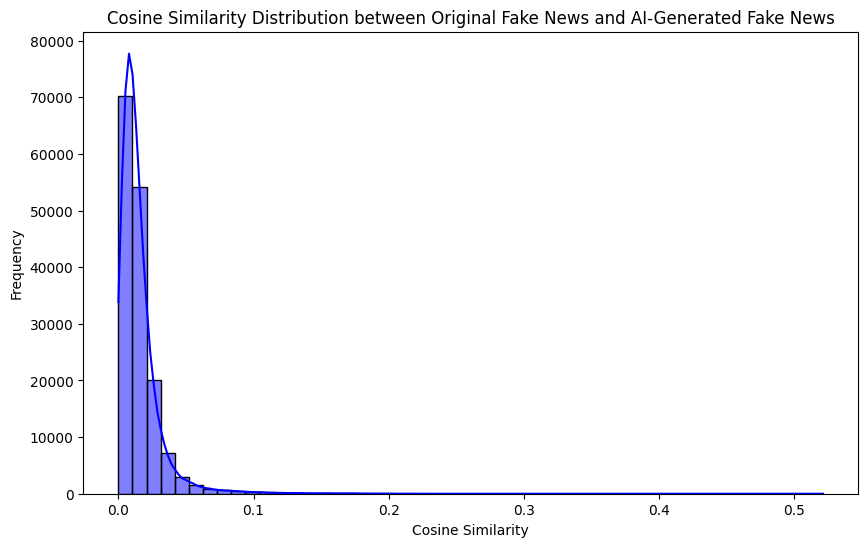

Comparing sentiment analysis...


/tmp/ipykernel_5033/4111264303.py:71: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(sentiment1, color='blue', label=label1, shade=True)
/tmp/ipykernel_5033/4111264303.py:72: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(sentiment2, color='red', label=label2, shade=True)


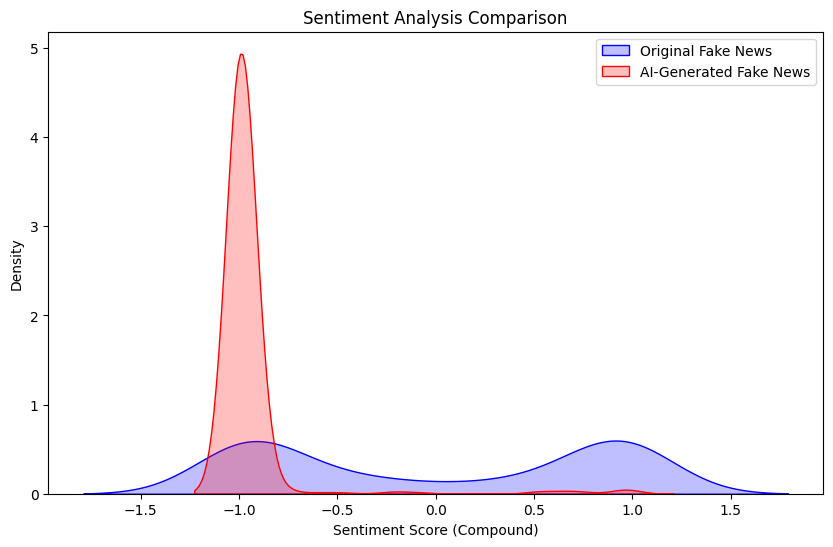

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download necessary NLTK data
nltk.download('vader_lexicon')

# Load the original fake news dataset and AI-generated fake news dataset
original_fake_news_df = pd.read_csv('evaluation_data/sampled_fake_news.csv')
ai_fake_news_df = pd.read_csv('evaluation_data/ai_generated_fake_news.csv')

# Helper function to calculate cosine similarity
def calculate_cosine_similarity(texts1, texts2):
    vectorizer = TfidfVectorizer(stop_words='english')
    
    # Fit the vectorizer on the combined corpus
    combined_texts = texts1 + texts2
    tfidf_matrix = vectorizer.fit_transform(combined_texts)
    
    # Split the TF-IDF matrix back into the original two datasets
    tfidf_texts1 = tfidf_matrix[:len(texts1)]
    tfidf_texts2 = tfidf_matrix[len(texts1):]
    
    # Compute cosine similarity between the two sets of texts
    similarity_matrix = cosine_similarity(tfidf_texts1, tfidf_texts2)
    
    # Return the mean cosine similarity as an overall comparison metric
    return similarity_matrix

#
# Helper function for sentiment analysis
def sentiment_analysis(texts):
    sia = SentimentIntensityAnalyzer()
    
    # Calculate sentiment polarity scores
    sentiment_scores = [sia.polarity_scores(text)['compound'] for text in texts]
    
    return sentiment_scores

# 1. Cosine Similarity Comparison
# Function to plot the cosine similarity distribution
def plot_cosine_similarity_distribution(df1, df2, label1, label2):
    texts1 = df1['text'].tolist()
    texts2 = df2['text'].tolist()
    
    # Calculate the cosine similarity matrix
    similarity_matrix = calculate_cosine_similarity(texts1, texts2)
    
    # Flatten the matrix to get a list of cosine similarities
    cosine_similarities = similarity_matrix.flatten()
    
    # Plot the distribution of cosine similarities
    plt.figure(figsize=(10, 6))
    sns.histplot(cosine_similarities, bins=50, kde=True, color='blue')
    plt.title(f'Cosine Similarity Distribution between {label1} and {label2}')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.show()

# 2. Sentiment Analysis Comparison
def plot_sentiment_comparison(df1, df2, label1, label2):
    # Perform sentiment analysis on both datasets
    sentiment1 = sentiment_analysis(df1['text'].tolist())
    sentiment2 = sentiment_analysis(df2['text'].tolist())
    
    # Plot sentiment distribution
    plt.figure(figsize=(10, 6))
    sns.kdeplot(sentiment1, color='blue', label=label1, shade=True)
    sns.kdeplot(sentiment2, color='red', label=label2, shade=True)
    plt.title('Sentiment Analysis Comparison')
    plt.xlabel('Sentiment Score (Compound)')
    plt.legend()
    plt.show()

# Run the comparisons
print("Calculating cosine similarity...")
plot_cosine_similarity_distribution(original_fake_news_df, ai_fake_news_df, 'Original Fake News', 'AI-Generated Fake News')

print("Comparing sentiment analysis...")
plot_sentiment_comparison(original_fake_news_df, ai_fake_news_df, 'Original Fake News', 'AI-Generated Fake News')



visual for sentiment anaylsis

bias analysis

visual for bias analysis

finally human review and visual for it